# Week 2 — From raw claims to a patient cohort and lines of therapy
## Case: Diffuse Large B-Cell Lymphoma (DLBCL), 640 synthetic patients, medical + pharmacy claims

**Applied Data Science and AI in Pharma Commercial · Columbia DSI · Fall 2026 · Monday, September 21**

Last week you toured 60 GLUCOREN patients to learn what the columns *mean*. Tonight you do what a brand analyst does in the first week on an oncology brand:

1. **Profile** a raw claims extract and find what is wrong with it (there is always something).
2. **Build a cohort** from diagnosis codes with an explicit, documented rule — in SQL (DuckDB) and in pandas.
3. **Measure** the cohort rule against a ground truth we happen to have (because the data is synthetic).
4. **Turn drug codes into drug events**, and drug events into **lines of therapy (LOT)**.
5. **Read** the result the way a brand team will: 1L / 2L / 3L+ shares, time to next treatment, site of care.

The data is **synthetic**. 500 true DLBCL patients were generated with realistic regimens; 140 "decoy" patients and several kinds of noise (duplicate lines, missing NPIs, adjustments, back-dated claims, coverage gaps) were then added on purpose. No real patients, providers or plans are represented.

| file | grain | what it represents |
|---|---|---|
| `dlbcl_patients.csv` | one row per patient | vendor demographic file (age, sex, state, payer, a *vendor-reported* dx date) |
| `dlbcl_medical_claims.csv` | one row per **service line** | 837-style medical claims: ICD-10 diagnosis, CPT/HCPCS procedure, place of service, rendering NPI, allowed amount |
| `dlbcl_pharmacy_claims.csv` | one row per fill | NCPDP-style pharmacy claims: NDC, days' supply, prescriber NPI |
| `dlbcl_enrollment.csv` | one row per coverage spell | the "closed-claims" view: when the payer could actually see this patient |
| `dlbcl_providers.csv` | one row per NPI | specialty and state |
| `dlbcl_drug_master.csv` | one row per code | HCPCS J-code / NDC → drug name → class (the crosswalk) |


## 1. Setup — pandas *and* DuckDB
DuckDB lets you write SQL against DataFrames or CSVs directly, with no server. In industry most cohort logic is written in SQL (Snowflake/Databricks) and most modeling in Python, so you will use both.

In [1]:
import numpy as np, pandas as pd, duckdb, matplotlib.pyplot as plt
from pathlib import Path
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
NAVY, CORAL, ICE, TEAL = "#1E2761", "#FF6B6B", "#CADCFC", "#2A9D8F"

DATA = Path("data") if Path("data").exists() else Path(".")          # CSVs live in data/
INSTR = Path("instructor material") if Path("instructor material").exists() else DATA
patients   = pd.read_csv(DATA / "dlbcl_patients.csv", parse_dates=["vendor_reported_dx_date"])
medical    = pd.read_csv(DATA / "dlbcl_medical_claims.csv", parse_dates=["service_date"], dtype={"provider_npi": "string", "code": str})
pharmacy   = pd.read_csv(DATA / "dlbcl_pharmacy_claims.csv", parse_dates=["fill_date"], dtype={"ndc": str, "prescriber_npi": "string"})
enrollment = pd.read_csv(DATA / "dlbcl_enrollment.csv", parse_dates=["coverage_start", "coverage_end"])
providers  = pd.read_csv(DATA / "dlbcl_providers.csv", dtype={"provider_npi": "string"})
drug_master = pd.read_csv(DATA / "dlbcl_drug_master.csv", dtype={"code": str})

con = duckdb.connect()
for name, df in dict(patients=patients, medical=medical, pharmacy=pharmacy, enrollment=enrollment, providers=providers, drug_master=drug_master).items():
    con.register(name, df)
q = lambda sql: con.execute(sql).df()

print(f"patients {len(patients):,} · medical lines {len(medical):,} · pharmacy fills {len(pharmacy):,} · enrollment spells {len(enrollment):,}")

patients 640 · medical lines 33,172 · pharmacy fills 3,040 · enrollment spells 663


## 2. Profile before you trust
A vendor extract is never "the truth". Before building anything, run the same eight checks every time. Each one below finds a real problem in this file.

In [2]:
q('''
SELECT claim_type, code_type, COUNT(*) AS lines, COUNT(DISTINCT patient_id) AS patients,
       ROUND(SUM(allowed_amount)/1e6, 2) AS allowed_musd
FROM medical GROUP BY 1,2 ORDER BY lines DESC''')

,claim_type,code_type,lines,patients,allowed_musd
0,drug_admin,HCPCS,13721,545,156.20
1,procedure,HCPCS,13228,500,7.42
2,office_visit,CPT,4688,640,1.16
3,imaging,CPT,1022,500,1.67
4,procedure,CPT,513,500,0.62


In [3]:
# Check 1 — what diagnosis codes are actually in here? (You asked the vendor for DLBCL. You got a little more.)
q('''SELECT diagnosis_code, COUNT(*) AS lines, COUNT(DISTINCT patient_id) AS patients
     FROM medical GROUP BY 1 ORDER BY lines DESC''')

,diagnosis_code,lines,patients
0,C83.30,32622,597
1,C82.00,252,22
2,C82.90,126,12
3,C82.10,123,11
4,R59.0,49,48


In [4]:
# Check 2 — duplicate service lines (resubmissions carry a suffixed claim_id but identical content)
key = ["patient_id", "service_date", "provider_npi", "code", "diagnosis_code", "allowed_amount"]
dups = medical.duplicated(subset=key, keep=False)
print(f"lines that share an identical (patient, date, NPI, code, dx, amount) key: {dups.sum():,}  ({dups.mean():.1%})")
medical[dups].sort_values(key).head(6)

lines that share an identical (patient, date, NPI, code, dx, amount) key: 1,262  (3.8%)


,claim_id,patient_id,service_date,provider_npi,place_of_service,claim_type,code_type,code,code_desc,diagnosis_code,units,allowed_amount,payer
4,M100000005,PT00000,2025-06-26,1874414982,22,drug_admin,HCPCS,J9312,rituximab,C83.30,20,17714.88,Medicare
5,M100000005R,PT00000,2025-06-26,1874414982,22,drug_admin,HCPCS,J9312,rituximab,C83.30,20,17714.88,Medicare
11,M100000011,PT00000,2025-06-27,1874414982,22,drug_admin,HCPCS,J9370,vincristine,C83.30,4,1085.31,Medicare
12,M100000011R,PT00000,2025-06-27,1874414982,22,drug_admin,HCPCS,J9370,vincristine,C83.30,4,1085.31,Medicare
25,M100000023,PT00000,2025-08-07,1874414982,22,drug_admin,HCPCS,J9312,rituximab,C83.30,3,12846.15,Medicare
26,M100000023R,PT00000,2025-08-07,1874414982,22,drug_admin,HCPCS,J9312,rituximab,C83.30,3,12846.15,Medicare


In [5]:
# Check 3 — negative / zero amounts = adjustments and reversals, not services
print(medical.allowed_amount.describe().round(1))
print(f"\nnegative-amount lines: {(medical.allowed_amount < 0).sum():,}")

count     33172.0
mean       5036.5
std       21811.9
min      -17990.6
25%         221.5
50%         272.5
75%        7224.5
max      474069.8
Name: allowed_amount, dtype: float64

negative-amount lines: 198


In [6]:
# Check 4 — missing rendering provider
print(f"lines with missing provider_npi: {medical.provider_npi.isna().sum():,} ({medical.provider_npi.isna().mean():.1%})")
# Check 5 — NPIs in claims that do not exist in the provider master
unknown = set(medical.provider_npi.dropna()) - set(providers.provider_npi)
print(f"distinct NPIs in claims not in provider master: {len(unknown)}")

lines with missing provider_npi: 494 (1.5%)
distinct NPIs in claims not in provider master: 0


In [7]:
# Check 6 — claims dated before the vendor's reported diagnosis date (back-dated eligibility? data entry? a different disease?)
chk = medical.merge(patients[["patient_id", "vendor_reported_dx_date"]], on="patient_id")
early = chk[chk.service_date < chk.vendor_reported_dx_date - pd.Timedelta(days=30)]
print(f"lines more than 30 days BEFORE the vendor-reported dx date: {len(early):,} across {early.patient_id.nunique()} patients")
early[["patient_id", "service_date", "vendor_reported_dx_date", "claim_type", "diagnosis_code"]].head()

lines more than 30 days BEFORE the vendor-reported dx date: 12 across 12 patients


,patient_id,service_date,vendor_reported_dx_date,claim_type,diagnosis_code
300,PT00005,2020-07-30,2022-11-17,office_visit,C83.30
1256,PT00021,2020-09-30,2022-11-17,office_visit,C83.30
1521,PT00025,2019-10-29,2022-01-25,office_visit,C83.30
8070,PT00125,2019-09-14,2022-02-23,office_visit,C83.30
9896,PT00153,2022-04-28,2024-09-24,office_visit,C83.30


In [8]:
# Check 7 — coverage: how many patients have a gap or lose coverage after diagnosis?
spells = q('''SELECT patient_id, COUNT(*) AS n_spells, MIN(coverage_start) AS first_start, MAX(coverage_end) AS last_end
              FROM enrollment GROUP BY 1''')
print(spells.n_spells.value_counts().rename("patients").to_frame().T)
print(f"patients whose last coverage ends before 2026-06-30 (censored): {(spells.last_end < '2026-06-30').sum()}")

n_spells    1   2
patients  617  23
patients whose last coverage ends before 2026-06-30 (censored): 44


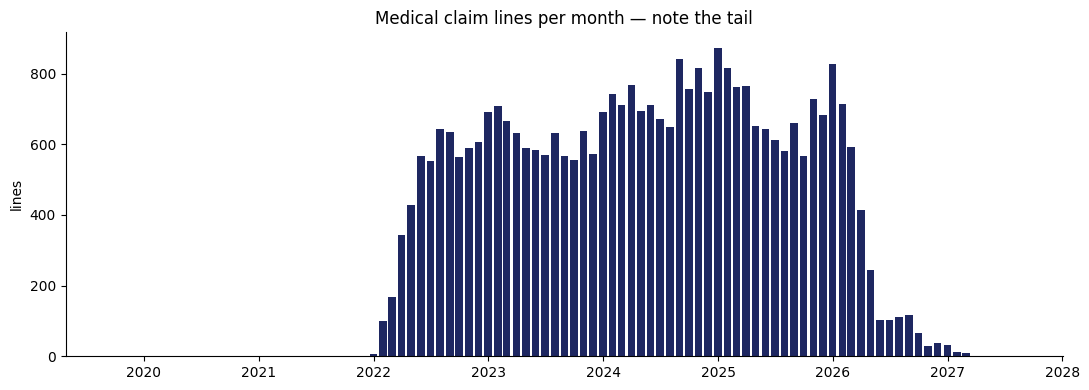

In [9]:
# Check 8 — time coverage of the extract (a truncated tail is the #1 cause of 'the brand is declining!' false alarms)
by_month = medical.set_index("service_date").resample("ME").size()
fig, ax = plt.subplots()
ax.bar(by_month.index, by_month.values, width=24, color=NAVY)
ax.set_title("Medical claim lines per month — note the tail"); ax.set_ylabel("lines")
plt.tight_layout(); plt.show()

**What we found.** Non-DLBCL codes (follicular lymphoma C82.x, a symptom code R59.0), ~2% duplicate lines, negative adjustment lines, missing NPIs, a few back-dated claims, and 8–12% of patients with coverage gaps or loss. None of this is unusual. The last chart matters most: claims arrive with a **lag** (weeks for pharmacy, months for medical), so the final 2–3 months of any extract are incomplete. Never compare the most recent quarter to the prior one without a completeness adjustment.

### Clean, and write down what you did

In [10]:
clean = medical.copy()
clean = clean[clean.allowed_amount > 0]                                   # drop adjustments/reversals
clean = clean.drop_duplicates(subset=key, keep="first")                    # drop resubmissions
clean["service_day"] = clean.service_date.dt.normalize()
print(f"medical lines: {len(medical):,} → {len(clean):,} after cleaning")
con.register("clean", clean)
CLEANING_LOG = ["dropped lines with allowed_amount <= 0 (adjustments)", "de-duplicated on (patient, date, NPI, code, dx, amount)"]

medical lines: 33,172 → 32,343 after cleaning


## 3. Build the cohort — with a rule you can defend
The most common cohort definition in claims analytics is the **"≥ 2 diagnosis claims on different days"** rule. It exists because a *single* diagnosis code is often a **rule-out** (the physician was checking) rather than a confirmed diagnosis.

Our definition for tonight (write yours down in every project):

| Element | Choice | Why |
|---|---|---|
| Disease code | ICD-10-CM `C83.30` (DLBCL, unspecified site) | The vendor extract was pulled on this code; in a real project use the full `C83.3*` family |
| Confirmation | ≥ 2 claims with the code on **different days**, the first two within **365 days** | One claim can be a rule-out; two a year apart can be surveillance of an old disease |
| Index date | first qualifying diagnosis day | Everything (lines of therapy, time-to-event) is measured from here |
| Baseline | continuously enrolled for **≥ 180 days before index** with no gap > 45 days | So we can see prior treatment (washout) — the *closed-claims* discipline |
| Follow-up | ≥ 1 day of enrollment after index (censor at coverage end) | Patients who vanish from the panel are censored, not dead |

### 3a. In SQL

In [11]:
cohort_sql = '''
WITH dx_days AS (                                   -- distinct diagnosis days per patient
    SELECT DISTINCT patient_id, service_day
    FROM clean WHERE diagnosis_code = 'C83.30'
), ranked AS (
    SELECT patient_id, service_day,
           ROW_NUMBER() OVER (PARTITION BY patient_id ORDER BY service_day) AS rn
    FROM dx_days
), first_two AS (
    SELECT patient_id,
           MAX(CASE WHEN rn = 1 THEN service_day END) AS dx1,
           MAX(CASE WHEN rn = 2 THEN service_day END) AS dx2,
           COUNT(*) AS n_dx_days
    FROM ranked GROUP BY patient_id
)
SELECT patient_id, dx1 AS index_date, dx2, n_dx_days,
       (dx2 IS NOT NULL) AS has_two_dx,
       (dx2 IS NOT NULL AND date_diff('day', dx1, dx2) <= 365) AS confirmed
FROM first_two
'''
cohort = q(cohort_sql)
print(f"patients with any C83.30 claim : {len(cohort):,}")
print(f"  … with ≥2 distinct dx days   : {cohort.has_two_dx.sum():,}")
print(f"  … first two within 365 days  : {cohort.confirmed.sum():,}")

patients with any C83.30 claim : 597
  … with ≥2 distinct dx days   : 525
  … first two within 365 days  : 490


### 3b. The same thing in pandas (so you can see it is not magic)

In [12]:
dx_days = (clean[clean.diagnosis_code == "C83.30"][["patient_id", "service_day"]].drop_duplicates()
           .sort_values(["patient_id", "service_day"]))
first_two = dx_days.groupby("patient_id").service_day.apply(lambda s: s.head(2).tolist())
pd_confirmed = {pid for pid, d in first_two.items() if len(d) == 2 and (d[1] - d[0]).days <= 365}
assert pd_confirmed == set(cohort[cohort.confirmed].patient_id), "SQL and pandas disagree"
print("SQL and pandas agree:", len(pd_confirmed), "confirmed patients")

SQL and pandas agree: 490 confirmed patients


### 3c. Add the enrollment criteria and build the attrition table
Every cohort you ever present should come with an **attrition (CONSORT-style) table**: how many patients you started with and how many each criterion removed. If a stakeholder cannot see the funnel, they will not trust the denominator.

In [13]:
cohort["index_date"] = pd.to_datetime(cohort.index_date)
enr = enrollment.copy()
def baseline_ok(pid, index_date, pre_days=180, max_gap=45):
    sp = enr[enr.patient_id == pid].sort_values("coverage_start")
    need_from = index_date - pd.Timedelta(days=pre_days)
    covered = sp[(sp.coverage_start <= index_date) & (sp.coverage_end >= need_from)]
    if covered.empty or covered.coverage_start.min() > need_from: return False
    # any gap > max_gap inside the baseline window?
    ends = covered.coverage_end.values[:-1]; starts = covered.coverage_start.values[1:]
    return all((pd.Timestamp(s) - pd.Timestamp(e)).days <= max_gap for e, s in zip(ends, starts))

def followup_end(pid, index_date):
    sp = enr[(enr.patient_id == pid) & (enr.coverage_end >= index_date)].sort_values("coverage_start")
    if sp.empty: return pd.NaT
    end = sp.iloc[0].coverage_end
    for _, r in sp.iloc[1:].iterrows():           # extend through contiguous spells (gap ≤ 45d)
        if (r.coverage_start - end).days <= 45: end = r.coverage_end
        else: break
    return end

conf = cohort[cohort.confirmed].copy()
conf["baseline_ok"] = [baseline_ok(p, d) for p, d in zip(conf.patient_id, conf.index_date)]
conf["followup_end"] = [followup_end(p, d) for p, d in zip(conf.patient_id, conf.index_date)]
conf["followup_days"] = (conf.followup_end - conf.index_date).dt.days
final = conf[conf.baseline_ok & (conf.followup_days >= 1)].copy()

attrition = pd.DataFrame([
    ("Patients in vendor extract", len(patients)),
    ("≥1 medical claim with C83.30", len(cohort)),
    ("≥2 distinct diagnosis days", int(cohort.has_two_dx.sum())),
    ("first two dx days within 365 d (index = first)", int(cohort.confirmed.sum())),
    ("≥180 d continuous enrollment before index (gap ≤ 45 d)", int(conf.baseline_ok.sum())),
    ("≥1 d enrollment after index → FINAL COHORT", len(final))], columns=["criterion", "patients"])
attrition["removed"] = -attrition.patients.diff().fillna(0).astype(int)
attrition

,criterion,patients,removed
0,Patients in vendor extract,640,0
1,≥1 medical claim with C83.30,597,43
2,≥2 distinct diagnosis days,525,72
3,first two dx days within 365 d (index = first),490,35
4,≥180 d continuous enrollment before index (gap...,482,8
5,≥1 d enrollment after index → FINAL COHORT,482,0


In [14]:
# Because the data is synthetic we can grade the rule. (The truth file is instructor-only; skip if absent.)
try:
    truth = pd.read_csv(INSTR / "_INSTRUCTOR_cohort_truth.csv")
    g = truth.merge(cohort[["patient_id", "confirmed"]], on="patient_id", how="left").fillna({"confirmed": False})
    g["in_cohort"] = g.patient_id.isin(final.patient_id)
    ct = pd.crosstab(g.cohort_truth, g.in_cohort, margins=True)
    print(ct)
    tp = ((g.cohort_truth == "true_dlbcl") & g.in_cohort).sum(); fn = ((g.cohort_truth == "true_dlbcl") & ~g.in_cohort).sum()
    fp = ((g.cohort_truth != "true_dlbcl") & g.in_cohort).sum(); tn = ((g.cohort_truth != "true_dlbcl") & ~g.in_cohort).sum()
    print(f"\nsensitivity {tp/(tp+fn):.1%}   specificity {tn/(tn+fp):.1%}   PPV {tp/(tp+fp):.1%}")
    lost = truth[(truth.cohort_truth == "true_dlbcl") & ~truth.patient_id.isin(final.patient_id)].patient_id
    print(); print(f"true DLBCL patients lost: {len(lost)} — {int(cohort[cohort.patient_id.isin(lost) & ~cohort.confirmed].shape[0])} failed the 365-day window (a single stray back-dated claim made their *first two* dx days years apart), the rest failed the enrollment criterion")
except FileNotFoundError:
    print("truth file not available in the student folder")

in_cohort            False  True  All
cohort_truth                         
follicular_lymphoma     45     0   45
rule_out_single_dx      70     0   70
true_dlbcl              19   481  500
two_dx_far_apart        24     1   25
All                    158   482  640

sensitivity 96.2%   specificity 99.3%   PPV 99.8%

true DLBCL patients lost: 19 — 11 failed the 365-day window (a single stray back-dated claim made their *first two* dx days years apart), the rest failed the enrollment criterion


**Discussion.** Specificity is near-perfect (one decoy slipped through — find it and explain how), but the rule threw away 19 real patients. Eleven of them were lost to *one back-dated claim each*: the "first two dx days within 365 days" rule is brittle to a single bad date. A more robust variant is "any two dx days within 365 days of each other" (try it). The other eight failed the enrollment criterion, which is a deliberate trade: we give up patients to gain a clean baseline.

A market-sizing analysis would happily accept the 2 mis-coded follicular patients and skip the enrollment criteria (more patients, small bias). An outcomes study or a payer dossier would not. There is no universally correct cohort — only a cohort that is **fit for the purpose** and **documented**.

## 4. From codes to drug events
Most DLBCL drugs are infused in a clinic, so they show up as **HCPCS J-codes on medical claims**, not as pharmacy fills. Oral agents (prednisone, lenalidomide, selinexor) show up as **NDCs on pharmacy claims**. You must combine both before you can see a regimen.

In [15]:
hcpcs_to_drug = drug_master[drug_master.code_type == "HCPCS"].set_index("code").drug_name.to_dict()
ndc_to_drug   = drug_master[drug_master.code_type == "NDC"].set_index("code").drug_name.to_dict()
drug_to_class = drug_master.set_index("drug_name").drug_class.to_dict()

med_drugs = clean[clean.claim_type == "drug_admin"].copy()
# lymphodepleting chemo given just before CAR-T is conditioning, not a line of therapy
med_drugs = med_drugs[~med_drugs.code_desc.str.contains("lymphodepletion", case=False, na=False)]
med_drugs["drug_name"] = med_drugs.code.map(hcpcs_to_drug)
unmapped = med_drugs[med_drugs.drug_name.isna()].code.value_counts()
print("unmapped HCPCS codes (should be empty or explainable):", unmapped.to_dict())
med_drugs = med_drugs.dropna(subset=["drug_name"]).rename(columns={"service_date": "date"})
med_drugs = med_drugs[["patient_id", "date", "drug_name", "provider_npi", "payer", "place_of_service"]].assign(source="medical")

ph_drugs = pharmacy.copy()
ph_drugs["drug_name"] = ph_drugs.ndc.str.zfill(11).map(ndc_to_drug).fillna(ph_drugs.drug_name)
ph_drugs = ph_drugs.rename(columns={"fill_date": "date", "prescriber_npi": "provider_npi"})
ph_drugs = ph_drugs[["patient_id", "date", "drug_name", "provider_npi", "payer"]].assign(source="pharmacy", place_of_service=np.nan)

drug_events = pd.concat([med_drugs, ph_drugs], ignore_index=True)
drug_events["drug_class"] = drug_events.drug_name.map(drug_to_class)
drug_events = drug_events[drug_events.patient_id.isin(final.patient_id)]          # cohort only
drug_events = drug_events.merge(final[["patient_id", "index_date"]], on="patient_id")
drug_events = drug_events[drug_events.date >= drug_events.index_date].sort_values(["patient_id", "date", "drug_name"]).reset_index(drop=True)
print(f"drug events in cohort, on/after index: {len(drug_events):,}   (medical {int((drug_events.source=='medical').sum()):,} · pharmacy {int((drug_events.source=='pharmacy').sum()):,})")
drug_events.drug_name.value_counts().head(12)

unmapped HCPCS codes (should be empty or explainable): {}
drug events in cohort, on/after index: 15,291   (medical 12,371 · pharmacy 2,920)


drug_name
rituximab              3029
cyclophosphamide       2844
prednisone             2843
doxorubicin            2648
vincristine            2105
polatuzumab vedotin     853
epcoritamab             232
glofitamab              188
bendamustine            114
carboplatin              65
etoposide                65
ifosfamide               65
Name: count, dtype: int64

**Sanity check:** rituximab and cyclophosphamide must top that list — they are in nearly every 1L regimen. If they don't, the crosswalk is broken.

## 5. Lines of therapy (LOT)
There is **no canonical LOT definition**. Every vendor, every consultancy and every brand team has one, and they differ. What matters is that yours is explicit. Ours (typical of DLBCL commercial work):

| # | Rule | Parameter |
|---|---|---|
| 1 | The first anti-lymphoma drug on/after index starts LOT 1 | — |
| 2 | Drugs first given within **W** days of a LOT start belong to that LOT's regimen | **W = 28 d** |
| 3 | A gap of more than **G** days with no anti-lymphoma drug ends the LOT; the next drug starts a new one | **G = 90 d** |
| 4 | A CAR-T infusion always starts a new LOT | — |
| 5 | Steroids alone never start a LOT (they ride along with the chemo they accompany) | 7-day look-back |

Change W or G and the shares change. That is why the parameters go on the slide, every time.

In [16]:
EXCLUDE_INITIATORS = {"prednisone", "dexamethasone"}
CART_DRUGS = {"axicabtagene ciloleucel", "lisocabtagene maraleucel", "tisagenlecleucel"}
W_REGIMEN_DAYS, G_GAP_DAYS = 28, 90

def assign_lots(df):
    df = df.copy().reset_index(drop=True)
    lot, current, last_date = [], 0, None
    for i, row in df.iterrows():
        date, drug = row.date, row.drug_name
        if drug in EXCLUDE_INITIATORS:
            recent = df.iloc[:i]
            recent = recent[(recent.date >= date - pd.Timedelta(days=7)) & (~recent.drug_name.isin(EXCLUDE_INITIATORS))]
            lot.append(current if (current > 0 and len(recent)) else np.nan)
            if current > 0 and len(recent): last_date = date
            continue
        if current == 0:
            current, last_date = 1, date; lot.append(current); continue
        if drug in CART_DRUGS or (date - last_date).days > G_GAP_DAYS:
            current += 1
        last_date = date; lot.append(current)
    df["lot"] = lot
    return df

ev = pd.concat([assign_lots(g) for _, g in drug_events.groupby("patient_id")], ignore_index=True)
ev = ev.dropna(subset=["lot"]).astype({"lot": int})
print("drug events by LOT:", ev.lot.value_counts().sort_index().to_dict())

drug events by LOT: {1: 13668, 2: 967, 3: 301}


In [17]:
import json
REGIMEN_DEFS = {k: set(v) for k, v in json.load(open(INSTR / "_INSTRUCTOR_regimens.json")).items()} if (INSTR / "_INSTRUCTOR_regimens.json").exists() else {
    "R-CHOP": {"rituximab","cyclophosphamide","doxorubicin","vincristine","prednisone"},
    "pola-R-CHP": {"polatuzumab vedotin","rituximab","cyclophosphamide","doxorubicin","prednisone"},
    "R-CVP": {"rituximab","cyclophosphamide","vincristine","prednisone"},
    "R-ICE": {"rituximab","ifosfamide","carboplatin","etoposide"}, "R-DHAP": {"rituximab","dexamethasone","cytarabine","cisplatin"},
    "Pola-BR": {"polatuzumab vedotin","bendamustine","rituximab"}, "Tafa-Len": {"tafasitamab","lenalidomide"},
    "axi-cel": {"axicabtagene ciloleucel"}, "liso-cel": {"lisocabtagene maraleucel"}, "tisa-cel": {"tisagenlecleucel"},
    "epcoritamab": {"epcoritamab"}, "glofitamab": {"glofitamab"}, "loncastuximab": {"loncastuximab tesirine"}, "selinexor": {"selinexor"}}
REGIMEN_DEFS.pop("R-mini-CHOP", None)   # same drug bag as R-CHOP; dose is invisible in claims

def match_regimen(bag):
    cart = bag & CART_DRUGS
    if cart: return {"axicabtagene ciloleucel": "axi-cel", "lisocabtagene maraleucel": "liso-cel", "tisagenlecleucel": "tisa-cel"}[next(iter(cart))]
    best, score = "Other / unmapped", 0.0
    for name, d in REGIMEN_DEFS.items():
        s = len(bag & d) / len(bag | d) + (0.2 if d <= bag else 0)
        if s > score: best, score = name, s
    return best if score >= 0.3 else "Other / unmapped"

rows = []
for (pid, lot), sub in ev.groupby(["patient_id", "lot"]):
    start = sub.date.min()
    bag = set(sub[sub.date - start <= pd.Timedelta(days=W_REGIMEN_DAYS)].drug_name)
    rows.append(dict(patient_id=pid, lot=lot, lot_start=start, lot_end=sub.date.max(), regimen=match_regimen(bag), drug_bag=", ".join(sorted(bag))))
per_lot = pd.DataFrame(rows)
print(f"LOT records: {len(per_lot):,} across {per_lot.patient_id.nunique()} treated patients")
per_lot.head(8)

LOT records: 670 across 481 treated patients


,patient_id,lot,lot_start,lot_end,regimen,drug_bag
0,PT00000,1,2025-06-26,2025-10-08,R-CHOP,"cyclophosphamide, doxorubicin, prednisone, rit..."
1,PT00001,1,2025-08-16,2025-11-30,pola-R-CHP,"cyclophosphamide, doxorubicin, polatuzumab ved..."
2,PT00002,1,2022-04-16,2022-08-01,R-CHOP,"cyclophosphamide, doxorubicin, prednisone, rit..."
3,PT00003,1,2025-07-16,2025-10-30,R-CHOP,"cyclophosphamide, doxorubicin, prednisone, rit..."
4,PT00004,1,2022-03-20,2022-07-04,R-CHOP,"cyclophosphamide, doxorubicin, prednisone, rit..."
5,PT00006,1,2026-01-08,2026-04-23,R-CHOP,"cyclophosphamide, doxorubicin, prednisone, rit..."
6,PT00007,1,2023-04-09,2023-07-26,R-CHOP,"cyclophosphamide, doxorubicin, prednisone, rit..."
7,PT00008,1,2025-02-18,2025-06-04,pola-R-CHP,"cyclophosphamide, doxorubicin, polatuzumab ved..."


## 6. The treatment landscape by line — what the brand team wants on slide 1

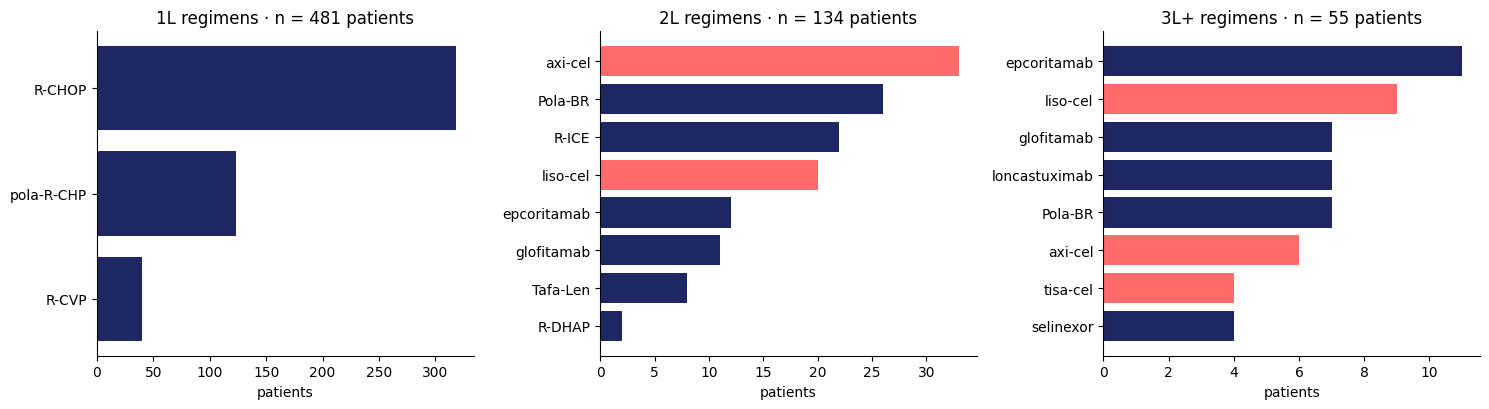

line,1L,2L,3L+
regimen,,,
Pola-BR,0.000,0.194,0.127
R-CHOP,0.661,0.000,0.000
R-CVP,0.083,0.000,0.000
R-DHAP,0.000,0.015,0.000
R-ICE,0.000,0.164,0.000
Tafa-Len,0.000,0.060,0.000
axi-cel,0.000,0.246,0.109
epcoritamab,0.000,0.090,0.200
glofitamab,0.000,0.082,0.127


In [18]:
share = (per_lot.assign(line=np.where(per_lot.lot >= 3, "3L+", per_lot.lot.map({1: "1L", 2: "2L"})))
         .groupby(["line", "regimen"]).size().rename("patients").reset_index())
share["share"] = share.patients / share.groupby("line").patients.transform("sum")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, line in zip(axes, ["1L", "2L", "3L+"]):
    s = share[share.line == line].sort_values("patients")
    ax.barh(s.regimen, s.patients, color=[CORAL if r in ("axi-cel", "liso-cel", "tisa-cel") else NAVY for r in s.regimen])
    ax.set_title(f"{line} regimens · n = {int(s.patients.sum())} patients"); ax.set_xlabel("patients")
plt.tight_layout(); plt.show()
share.pivot(index="regimen", columns="line", values="share").fillna(0).round(3)

**Reading it.** R-CHOP still dominates 1L with pola-R-CHP as the growing #2 — the post-POLARIX picture. 2L fragments: salvage chemo (R-ICE / R-DHAP, usually ahead of a transplant) competes with CAR-T (axi-cel, liso-cel) after ZUMA-7 / TRANSFORM. 3L+ is bispecifics and late CAR-T. Real analysts would immediately cut this by age band, payer and site of care — because CAR-T eligibility, access and referral differ sharply on each (see the IQVIA CAR-T referral paper in the reading pack: two of three eligible R/R LBCL patients are never referred).

## 7. Time to next treatment (TTNT) — the closest a claims file gets to an outcome

     count   mean    25%    50%    75%
lot                                   
1    134.0  450.0  350.0  438.0  559.0
2     55.0  287.0  198.0  283.0  379.0


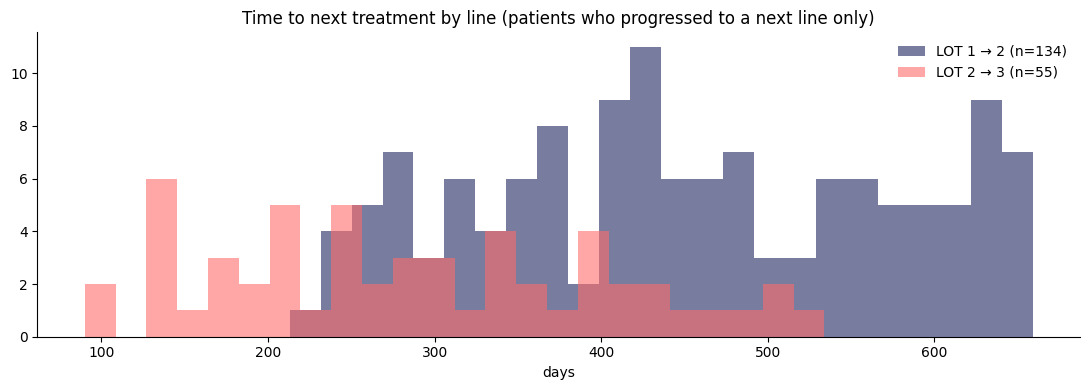

In [19]:
per_lot = per_lot.sort_values(["patient_id", "lot"])
per_lot["ttnt_days"] = per_lot.groupby("patient_id").lot_start.shift(-1).sub(per_lot.lot_start).dt.days
summary = per_lot.dropna(subset=["ttnt_days"]).groupby("lot").ttnt_days.describe()[["count", "mean", "25%", "50%", "75%"]].round(0)
print(summary)
fig, ax = plt.subplots()
for L, c in [(1, NAVY), (2, CORAL)]:
    s = per_lot[(per_lot.lot == L)].ttnt_days.dropna()
    ax.hist(s, bins=24, alpha=0.6, color=c, label=f"LOT {L} → {L+1} (n={len(s)})")
ax.set_title("Time to next treatment by line (patients who progressed to a next line only)"); ax.set_xlabel("days"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Censoring warning.** TTNT is computed only for patients who *had* a next line. Patients who were cured, died, or **left the panel** (lost coverage — check the enrollment file) are missing from this histogram. A proper analysis uses a Kaplan–Meier curve with censoring at `followup_end`; you will see that in Week 6. Never present a mean TTNT without saying who is excluded.

## 8. Site of care and payer — cuts the brand team will ask for next

In [20]:
first_line = per_lot[per_lot.lot == 1].merge(patients[["patient_id", "payer", "age_at_dx"]], on="patient_id")
first_line["age_band"] = pd.cut(first_line.age_at_dx, [0, 60, 70, 80, 120], labels=["<60", "60–69", "70–79", "80+"])
print("1L regimen share by payer (columns sum to 1):")
print(pd.crosstab(first_line.regimen, first_line.payer, normalize="columns").round(2))
print("\nCAR-T (any line) by age band — eligibility falls with age and frailty:")
cart_pts = per_lot[per_lot.regimen.isin(["axi-cel", "liso-cel", "tisa-cel"])].patient_id.unique()
fl = first_line.assign(got_cart=first_line.patient_id.isin(cart_pts))
print(fl.groupby("age_band", observed=True).got_cart.mean().round(3).rename("share receiving CAR-T"))

1L regimen share by payer (columns sum to 1):
payer       Commercial  Medicaid  Medicare
regimen                                   
R-CHOP            0.65      0.66      0.67
R-CVP             0.10      0.08      0.07
pola-R-CHP        0.25      0.26      0.26

CAR-T (any line) by age band — eligibility falls with age and frailty:
age_band
<60      0.200
60–69    0.154
70–79    0.075
80+      0.000
Name: share receiving CAR-T, dtype: float64


In [21]:
# Site of care from place-of-service codes on the infusion lines (11 office · 22 hospital outpatient · 21 inpatient)
pos = (ev[ev.source == "medical"].groupby("place_of_service").size().rename("infusion lines"))
pos.index = pos.index.map({11: "11 · physician office", 21: "21 · inpatient", 22: "22 · hospital outpatient"})
print(pos)
print("\nWhy it matters: hospital-outpatient infusions may be billed under 340B (Week 1) and inpatient drugs are often bundled into a DRG — invisible line-by-line.")

place_of_service
21 · inpatient                 72
22 · hospital outpatient    12298
Name: infusion lines, dtype: int64

Why it matters: hospital-outpatient infusions may be billed under 340B (Week 1) and inpatient drugs are often bundled into a DRG — invisible line-by-line.


## 9. What to take away
1. **Profile first.** Duplicates, adjustments, missing keys, back-dated claims, coverage gaps and the lag tail are in every extract. Write a cleaning log.
2. **A cohort is a rule, not a fact.** ≥2 dx / 365-day window / enrollment criteria — each is a sensitivity-vs-specificity choice. Publish the attrition table.
3. **Oncology lives in medical claims.** J-codes, not NDCs. Combine both sources before you say anything about regimens.
4. **LOT parameters (W, G, CAR-T rule) go on the slide.** Different defaults give different shares.
5. **Censoring is not death.** Pair claims with enrollment (closed claims) or mortality data before interpreting time-to-event.

### Try before Week 3 (not graded)
- Re-run the cohort with a 730-day window and *no* enrollment criteria. How many patients change? Which decoys get in?
- Set `G_GAP_DAYS = 60`. What happens to the 2L share of CAR-T, and why?
- Write the cohort attrition query so it runs in one DuckDB statement (hint: `QUALIFY` and window functions).
